## Inversion for a coupled acoustic-gravity system

Before running `pip install tinyda ray' 

### Problem setup

Let $\varphi$ be the potential for the flow velocity, it is solution to 
\begin{align}\label{eq:forwardmodel}
    \frac{\partial^2 \varphi}{\partial t^2}
    - c^2 \Delta \varphi 
    + g \frac{\partial \varphi}{\partial z}
    = 0,  \quad \text{ in } \Omega,
    \\
    \frac{\partial^2 \varphi}{\partial t^2}
    + g \frac{\partial \varphi}{\partial z} 
    = 0, \quad \text{ on } \Gamma_s,
    \\
    \nabla \varphi \cdot {\bf n}
    = u_b, \quad \text{ on } \Gamma_b,
\end{align}
where $c$ is the (constant) sound speed, $g$ is the gravity acceleration, ${\bf n}$ is the outwards unit vector normal to the seabed $\Gamma_b$ and $u_b$ is the seabed velocity.
The fluid displacement $u$ is related to the potential by $u = \nabla \varphi$.

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist

import tinyDA as tda
import umbridge

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-21 11:34:02,998	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Load data and get stats

In [2]:
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# convert the tinyDA chains to an ArViz InferenceData object.
folder_data = "../../../../data_from_cluster/"
idata = az.from_netcdf(folder_data+"2026_08_20_envelope.nc") # to load

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [4]:
print(idata)
print(idata.sample_stats)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> qoi
<xarray.Dataset> Size: 560kB
Dimensions:     (chain: 2, draw: 10001)
Coordinates:
  * chain       (chain) int64 16B 0 1
  * draw        (draw) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999 10000
Data variables:
    prior       (chain, draw) float64 160kB ...
    likelihood  (chain, draw) float64 160kB ...
    posterior   (chain, draw) float64 160kB ...


In [5]:
# display posterior summary statistics.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)
info = az.summary(idata);
info

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,0.041,0.994,-1.748,1.939,0.013,0.009,6250.0,6455.0,1.0
x1,0.050,0.992,-1.752,1.962,0.013,0.009,6217.0,7265.0,1.0
x2,0.063,0.989,-1.848,1.858,0.013,0.009,6234.0,7298.0,1.0
x3,0.084,0.986,-1.774,1.921,0.012,0.009,6458.0,7562.0,1.0
x4,0.109,0.986,-1.825,1.902,0.012,0.009,6676.0,7306.0,1.0
x5,0.126,0.986,-1.755,1.933,0.012,0.008,6844.0,6130.0,1.0
x6,0.138,0.991,-1.726,1.964,0.012,0.009,6807.0,5575.0,1.0
x7,0.145,0.996,-1.802,1.952,0.012,0.009,6833.0,5693.0,1.0
x8,0.149,1.000,-1.772,1.962,0.012,0.009,6763.0,6061.0,1.0
x9,0.153,1.001,-1.705,2.016,0.012,0.009,6784.0,6914.0,1.0


/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


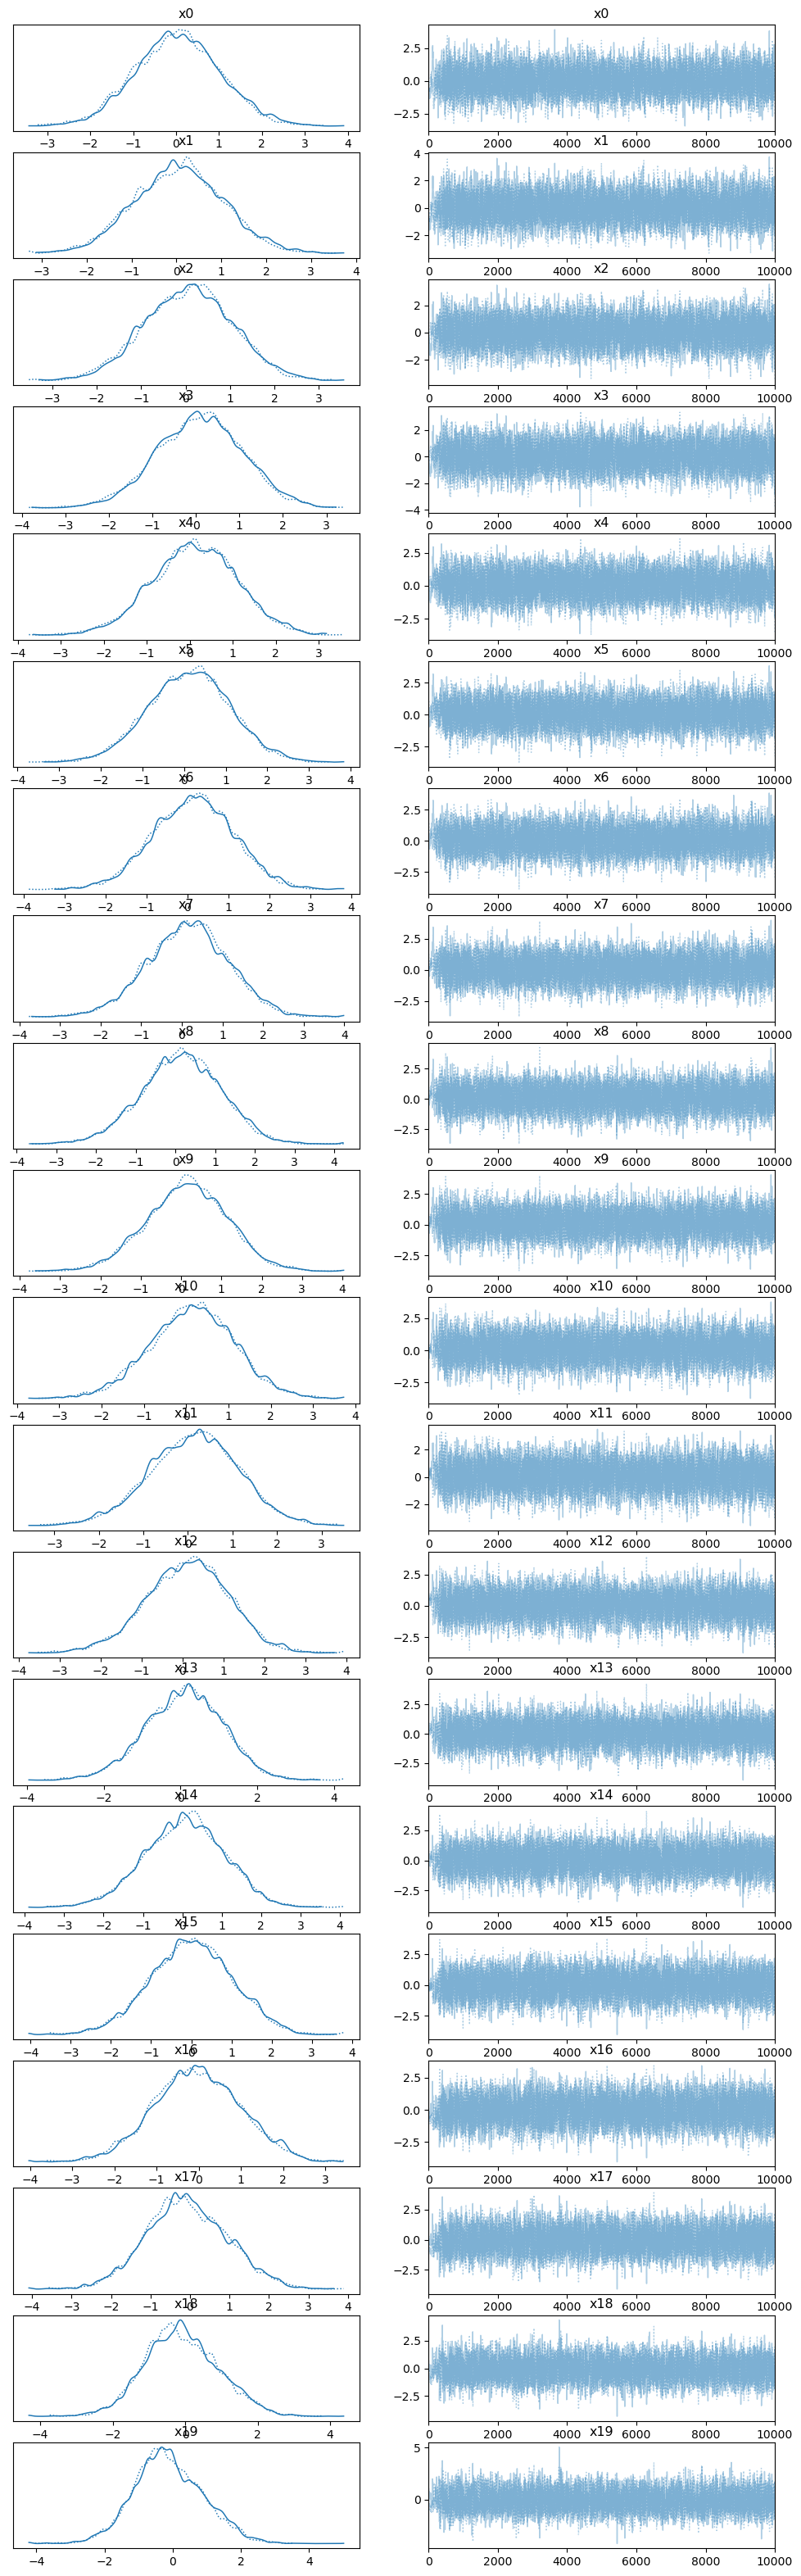

In [6]:
# plot posterior kernel densities and traces.
az.plot_trace(idata)
plt.show()

In [7]:
# extract the parameters from the chains.
subsampling_rate = 1
burnin = 500
#parameters = [link.parameters for link in my_chains['chain_0'][burnin::subsampling_rate] + my_chains['chain_1'][burnin::subsampling_rate]]

# If loaded data need to do this, otherwise above is easier
idata_sub = idata.sel(draw=slice(burnin, None, subsampling_rate))
parameters = [
    np.array([idata_sub.posterior[var].values[0, i] for var in idata_sub.posterior.data_vars])
    for i in range(idata_sub.posterior.draw.size)
]

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (200) in plot_autocorr, generating only 40 plots
  warnings.warn(


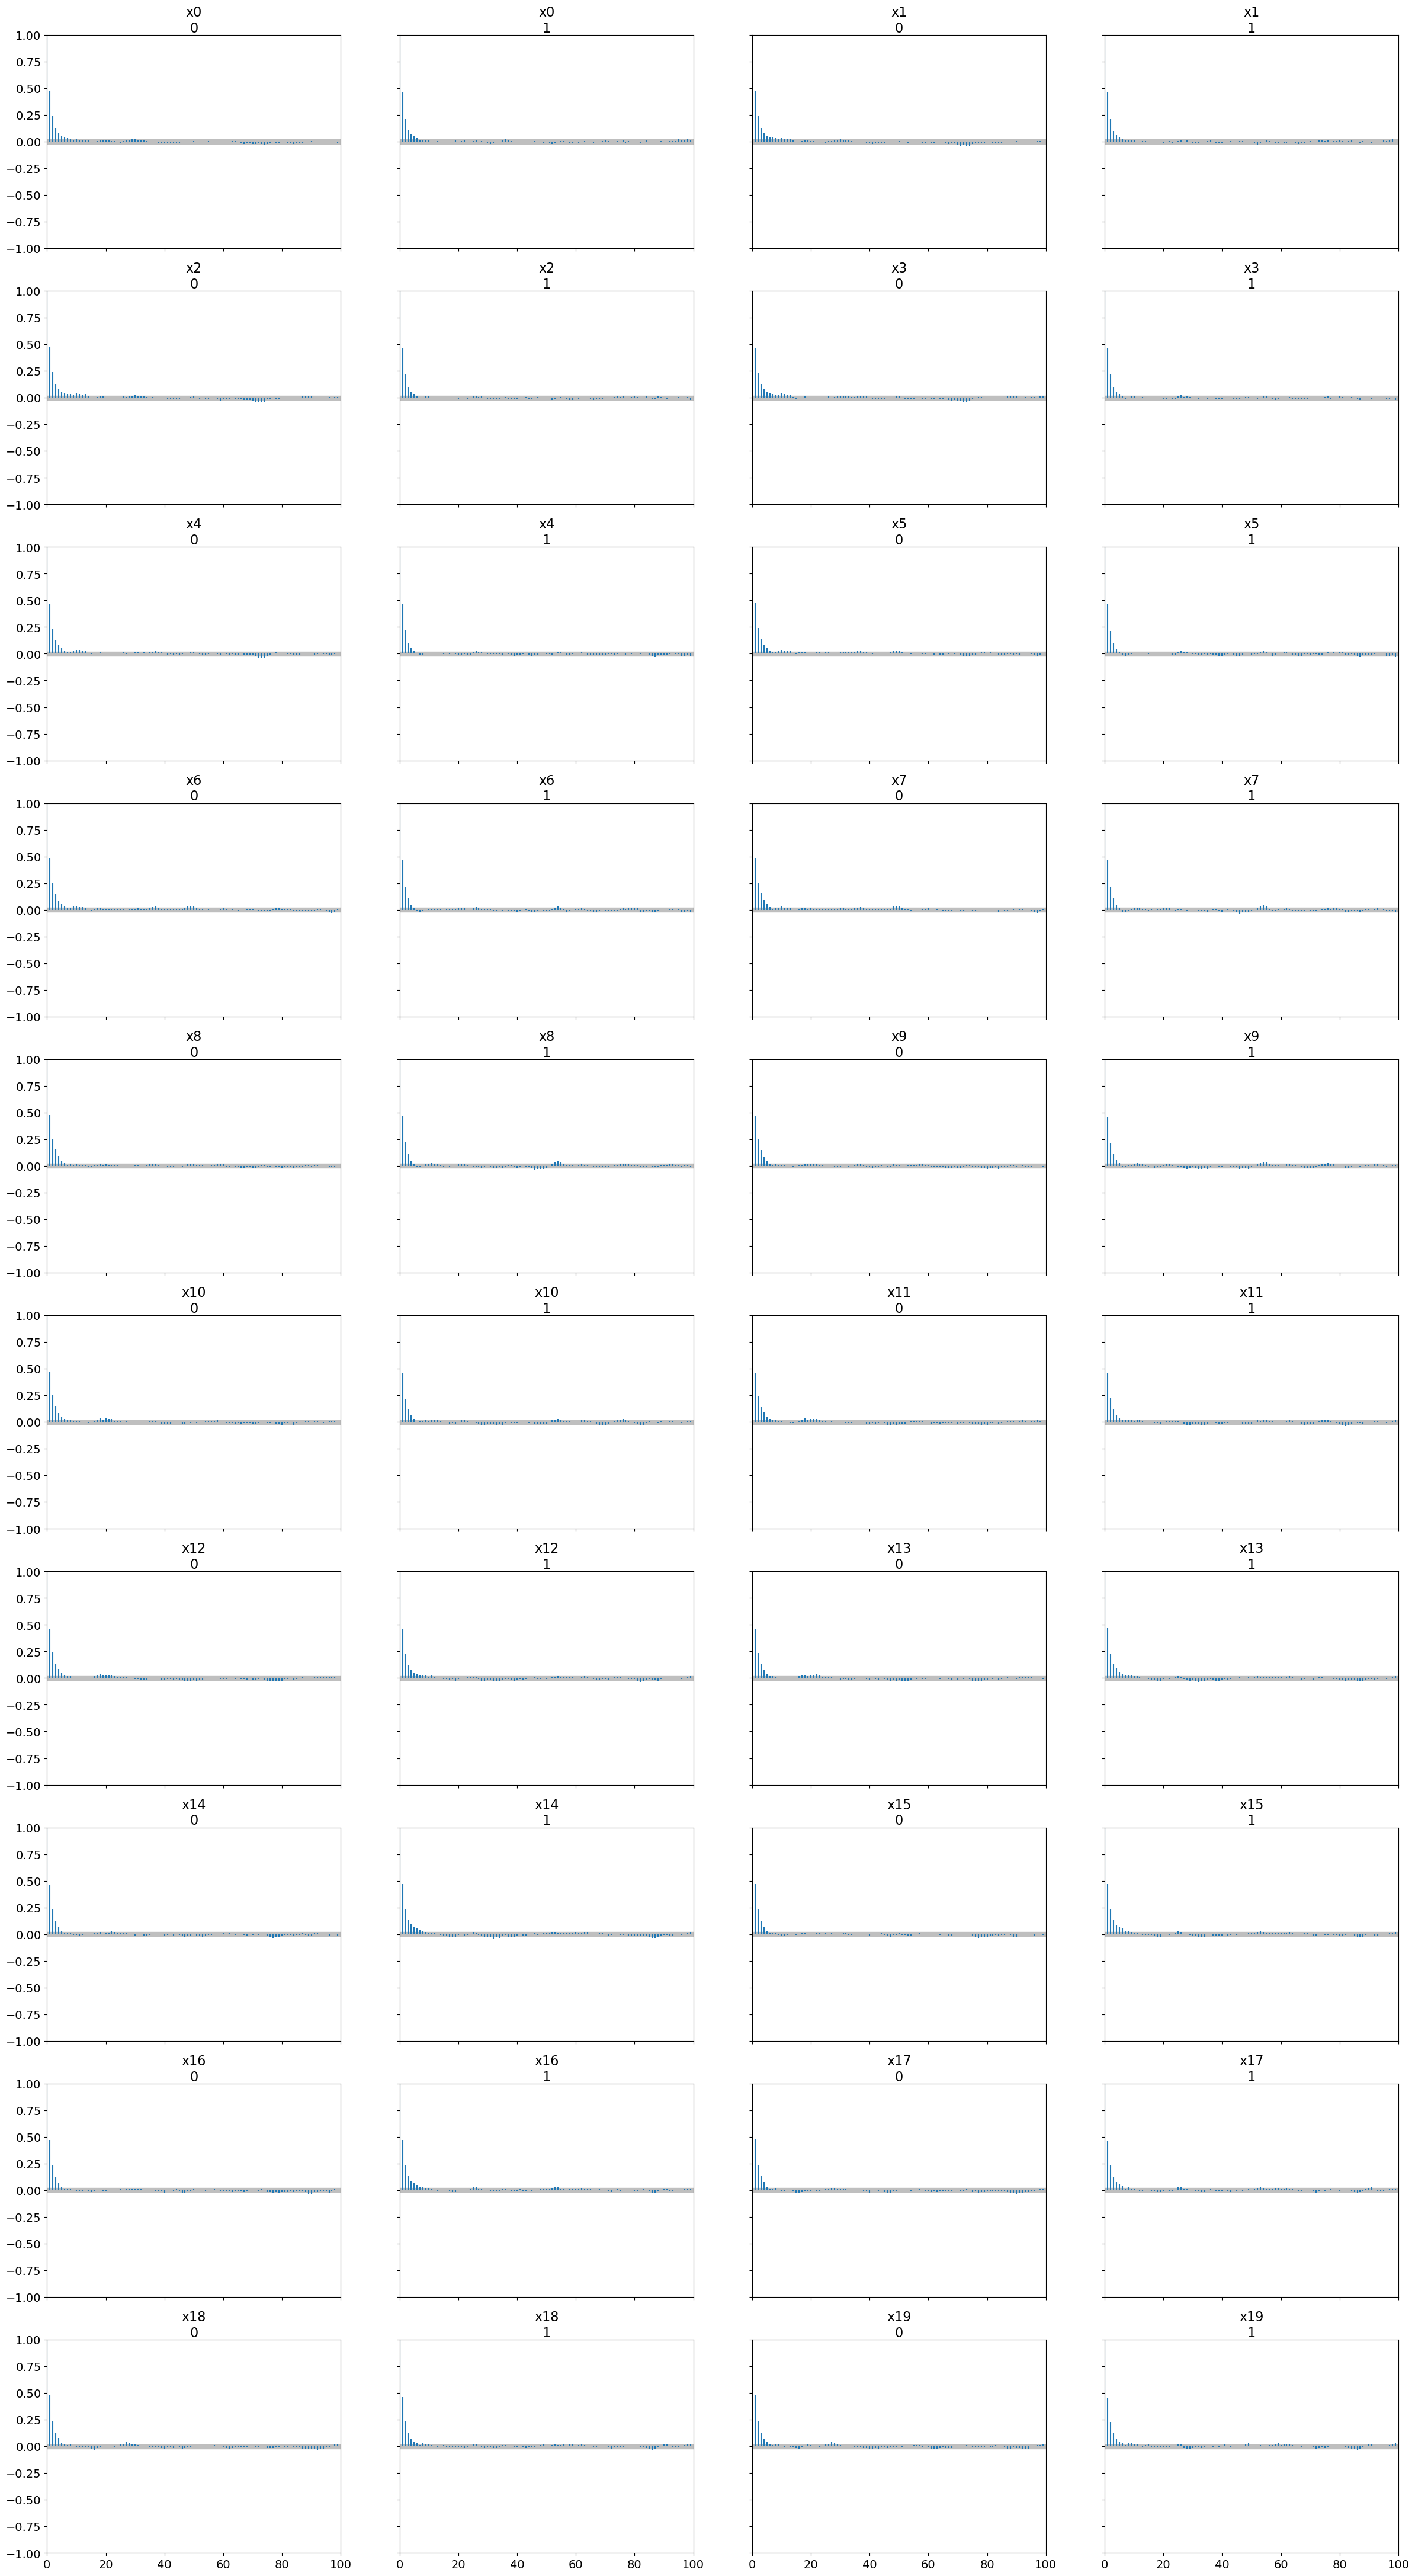

In [21]:
az.plot_autocorr(idata);

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (100) in plot_posterior, generating only 40 plots
  warnings.warn(


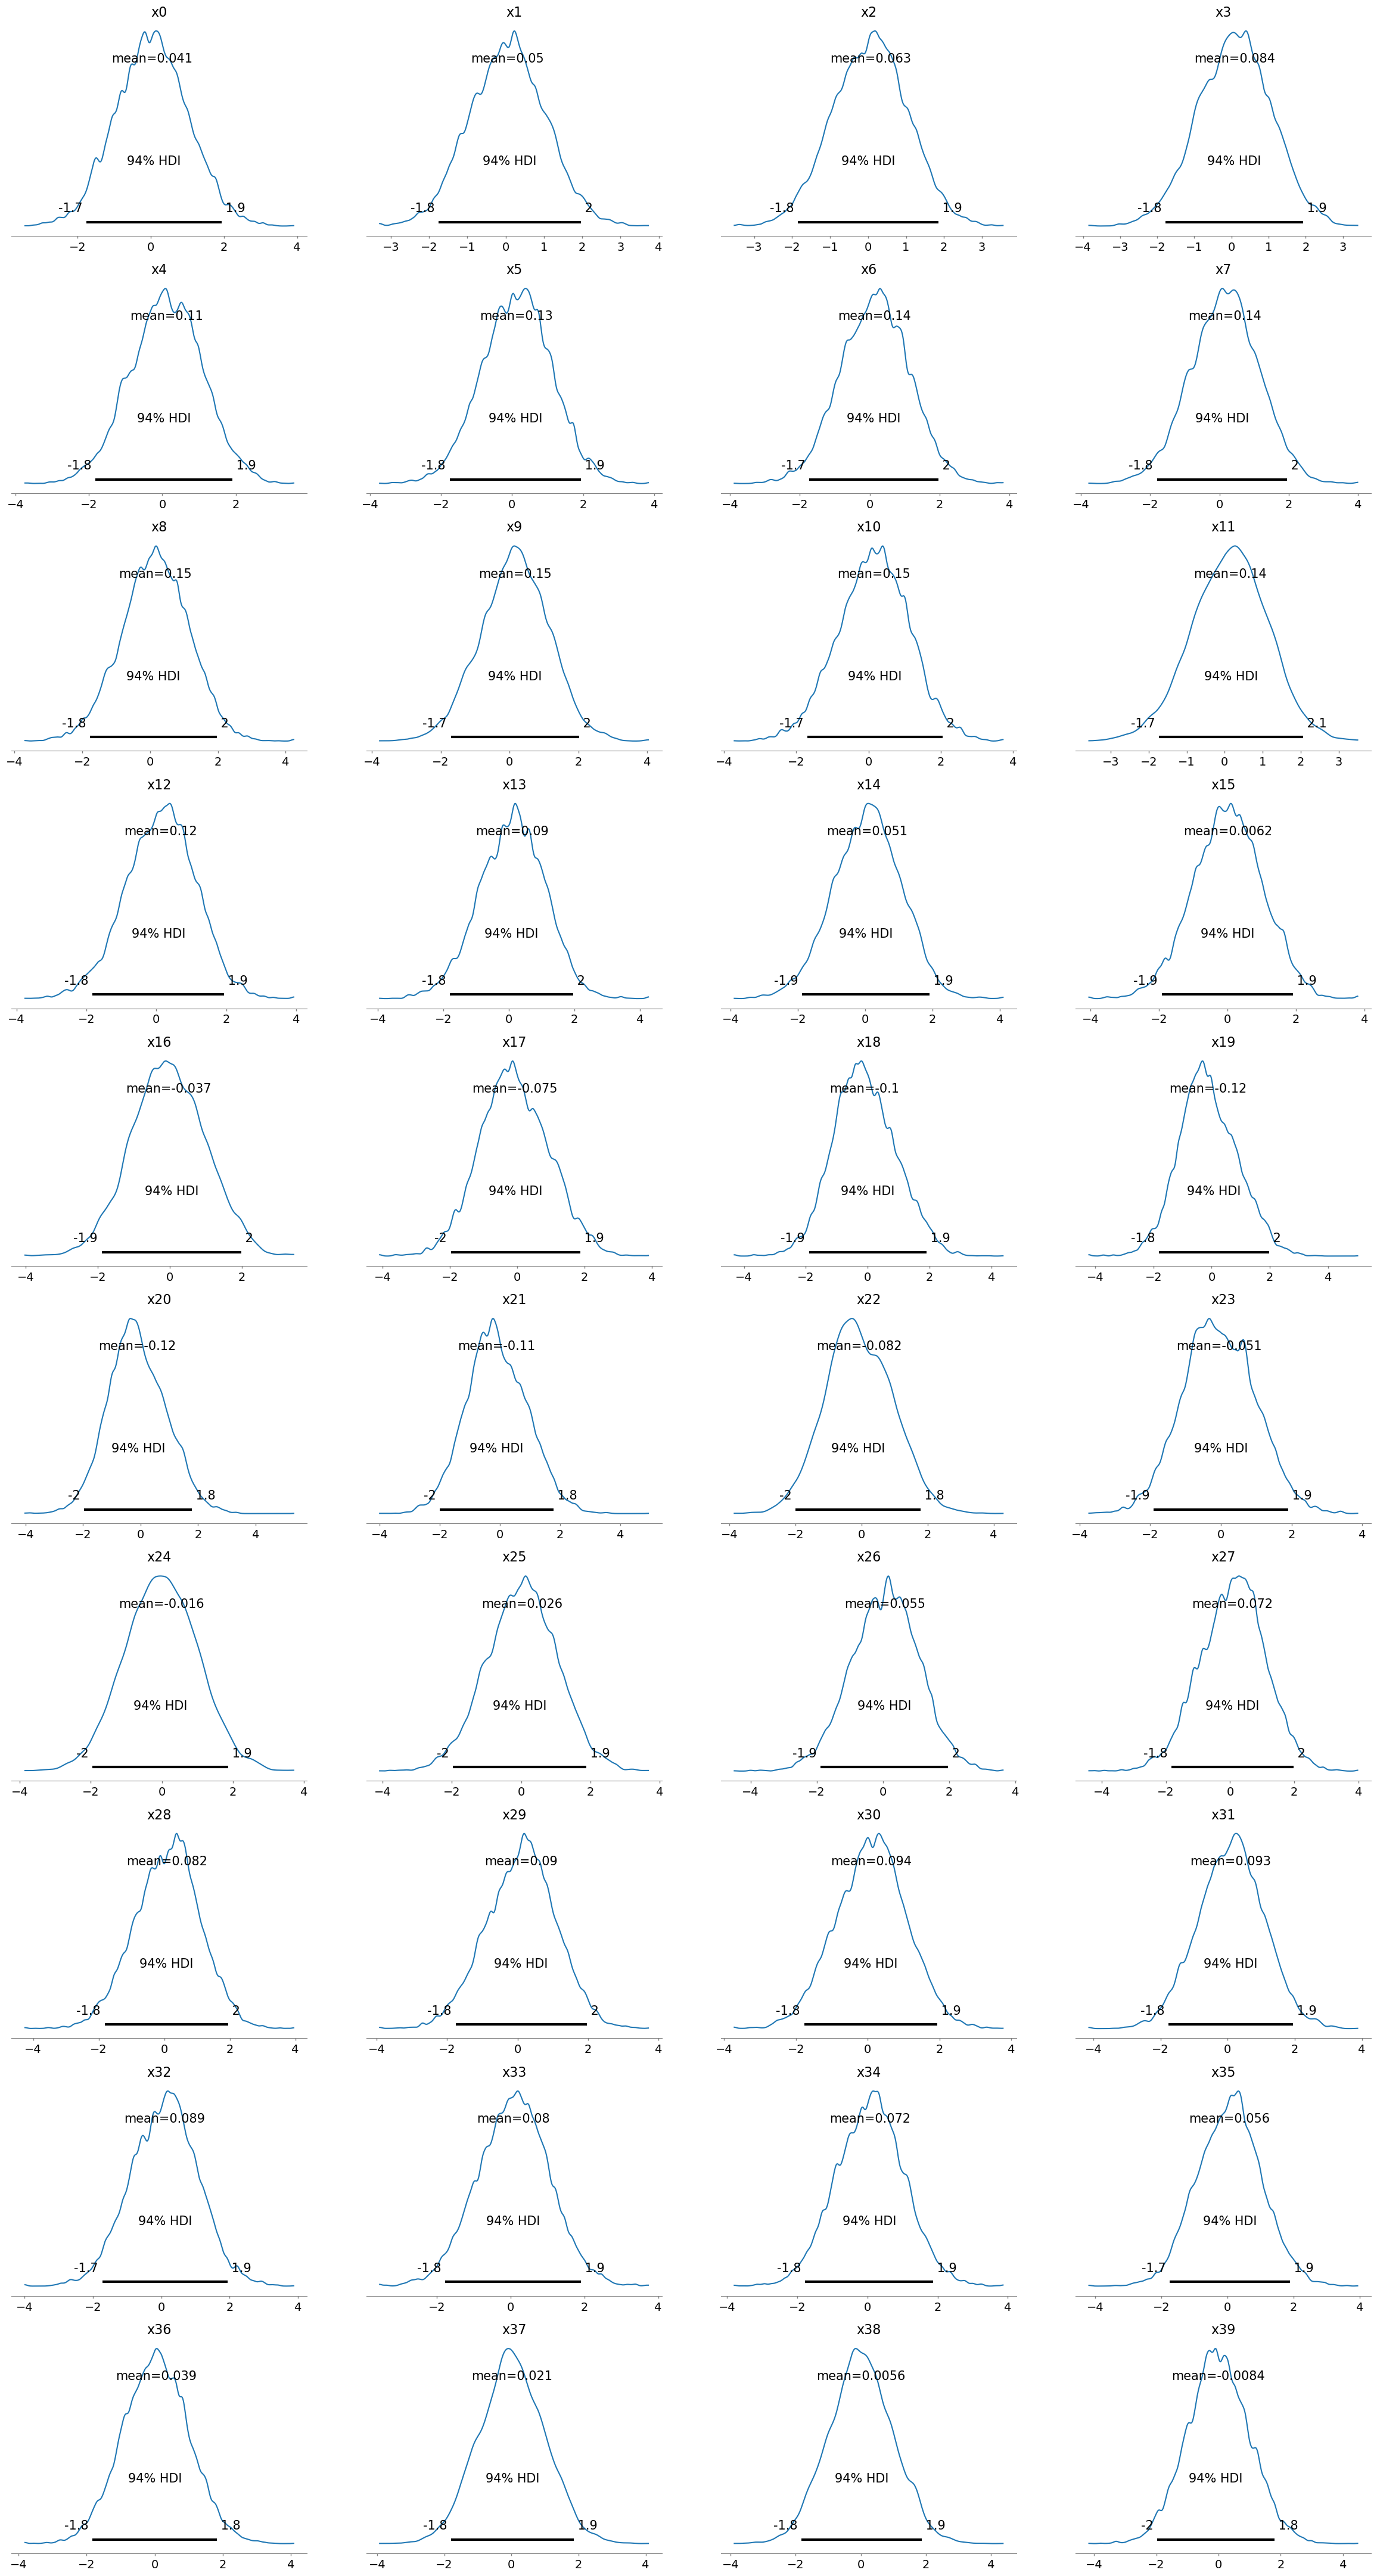

In [22]:
az.plot_posterior(idata);

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/arviz/plots/plot_utils.py:272: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (100) in plot_rank, generating only 40 plots
  warnings.warn(


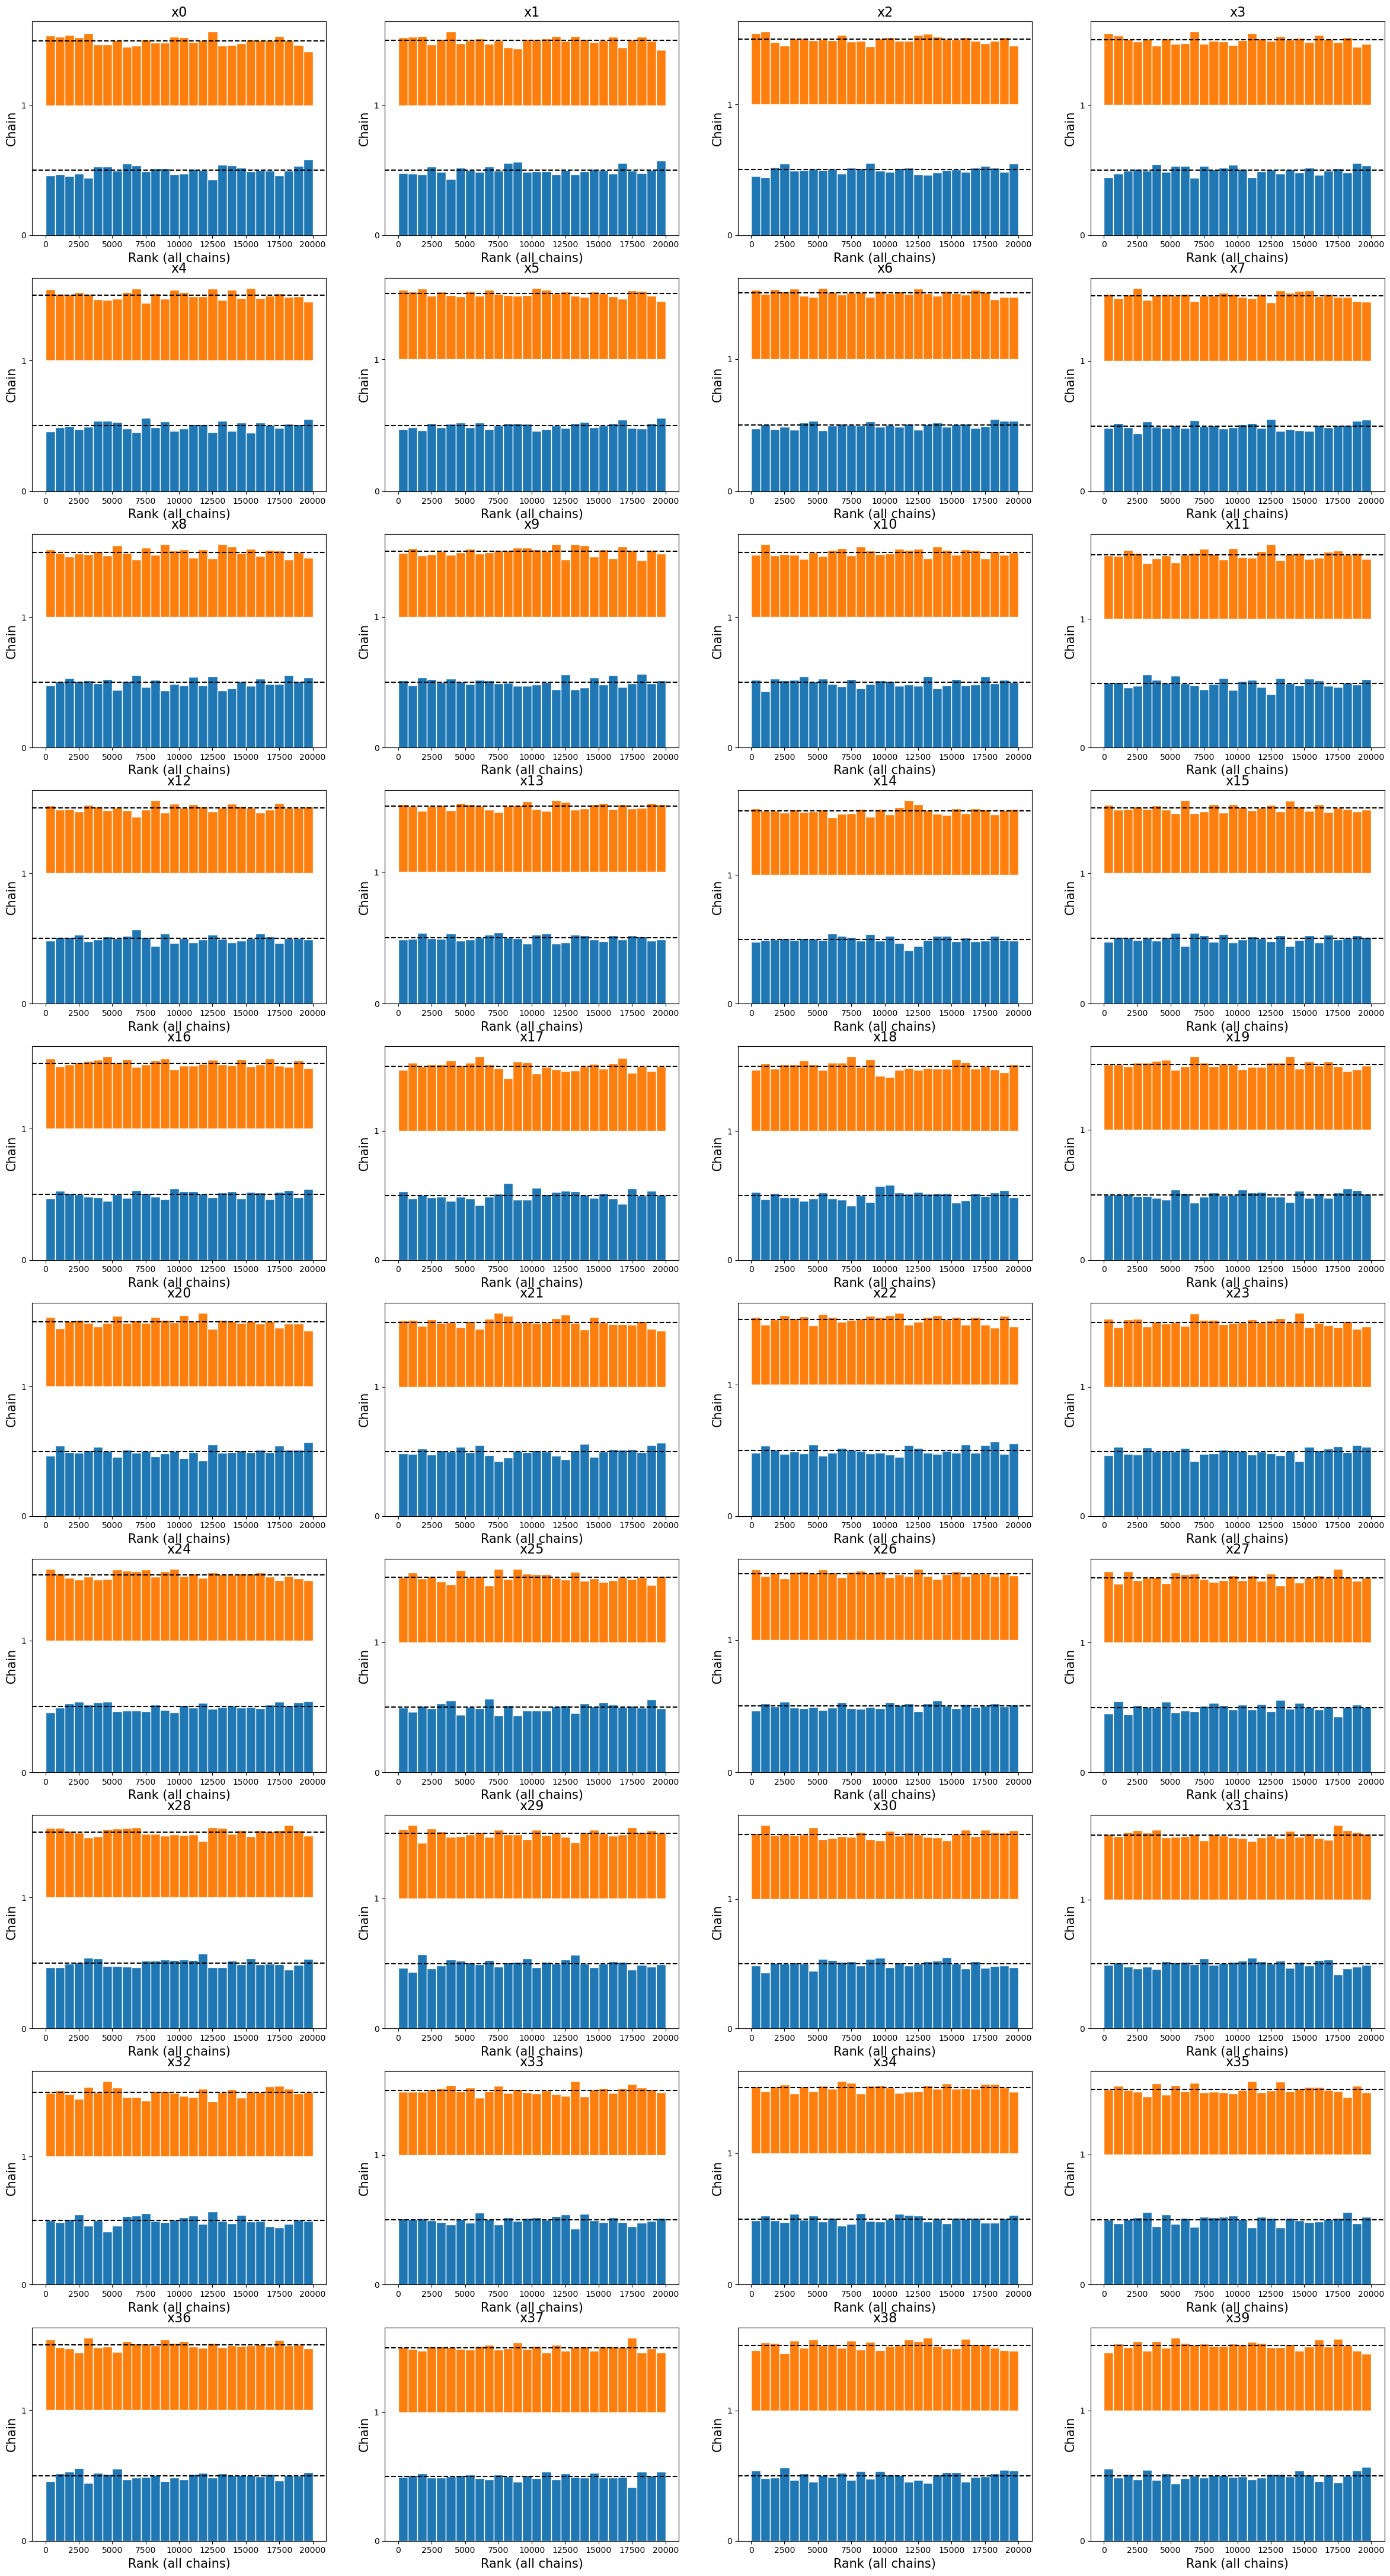

In [23]:
az.plot_rank(idata);

# Compare to true data

## Define model parameters

Note: for this part it would be better to get the results directly from the python script

In [8]:
# Set domain size and simulation time: this info is shared between the forward and parameter models 
Lx = 20
Lz = 1 
TEnd = 10 
H = 1.5

# Define sensors
# Each element of the list "captors" is a tuple of (x,z) coordinates. 
# Coordinates are given in the (scaled) domain: x \in [0, grid_size_x], z \in [0, grid_size_y]
sensors = [(4,0.8), (13.5, 0.6)]

# Create sorted sensor list to pass to the forward model: do not change this part 
sensors_sort = np.array(sensors, dtype=[('x',float),('y',float)])
sensors_sort = np.sort(sensors_sort, order=['x','y'])
sensors = sensors_sort.tolist()
n_sensors = len(sensors)
print("Number of sensors:", n_sensors)


nx, ny = 100, 202 # TODO: this can change based on the model 
print(f"input:{nx}, output:{ny}")

Number of sensors: 2
input:100, output:202


In [9]:
# Generate synthetic data
exact = np.zeros(nx)
# True source in the middle of the domain 
idx_middle = int(nx/2)
source_width = 4 # in length unit 
idx_width = int(0.5 * source_width / Lx * nx )
exact[idx_middle - idx_width : idx_middle + idx_width]=1

In [10]:
# Define functions to process the input of the model

# Level-set parameter
eps = 1e-6

def restriction(sampin):
    field_cut = sampin
    return (field_cut > eps).astype(int)

## Outputs where running the forward model is not needed

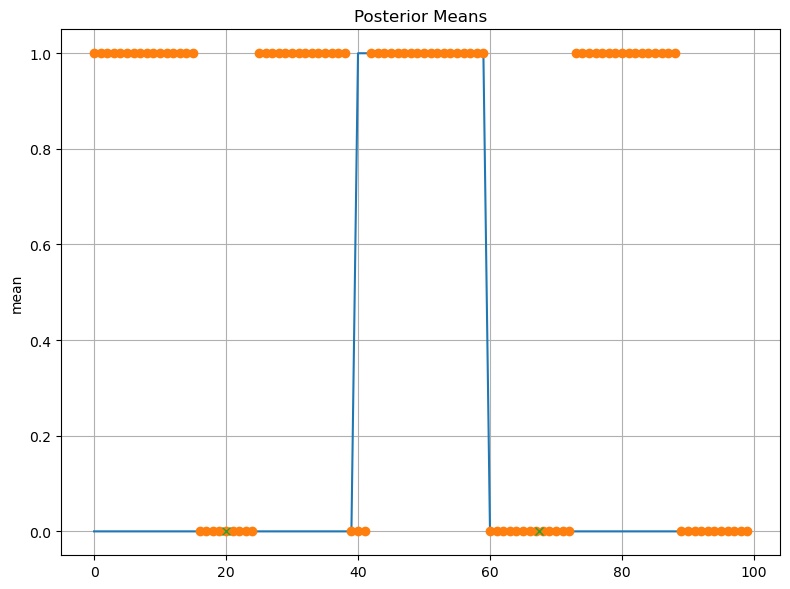

In [11]:
# Plot mean posterior against synthetic data
x = range(len(info))
plt.figure(figsize=(8, 6))
plt.plot(exact)
plt.title('Exact input')
plt.plot(x, restriction(info['mean']), 'o')  # x = index, y = mean
#plt.plot(x, info['mean'], 'x')  # x = index, y = mean
#print(top_links[0])
#plt.plot(x, restriction(parameters[top_indices[0]]), 'x')  # x = index, y = mean
plt.plot([sensors[0][0]*nx/Lx,sensors[1][0]*nx/Lx],[0,0],'x')
plt.ylabel('mean')
plt.title('Posterior Means')
plt.grid(True)
plt.tight_layout()
plt.show()

## Outputs where running the forward model is needed

In [12]:
# connect to the UM-Bridge model.
umbridge_model = umbridge.HTTPModel('http://localhost:4242', "forward")

# wrap the UM-Bridge model in the tinyDA UM-Bridge interface.
config = {"captors":sensors}

# my_model = tda.UmBridgeModel(umbridge_model) # DG: for now without config 
my_model = tda.UmBridgeModel(umbridge_model, umbridge_config=config)

# For now the DG file does not use the arg config 
nx = umbridge_model.get_input_sizes(config)[0] #the input is the value of f(x) at each grid point
ny = umbridge_model.get_output_sizes(config)[0] #the outout is a time series of the pressure

d_true = my_model(exact)

In [13]:
## Define functions needed 
def levelset_model(parameters):
    levelset_params = restriction(parameters)
    return my_model(levelset_params)


# GRF parameters
length_scale = 1
decay_rate = 10

# Use this covariance structure moving forward to match theory
def matern32_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    sqrt3 = np.sqrt(3.0)
    scaled_dists = sqrt3 * dists / length_scale
    return variance * (1.0 + scaled_dists) * np.exp(-scaled_dists)


dx = Lx/nx
x = np.linspace(0, Lx, nx).reshape(-1, 1)
cov = matern32_covariance(x, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)
my_prior = multivariate_normal(mean=mean, cov=cov)

### Compare draws from the posteriors to the true data

In [ ]:
# Evaluate model outputs and likelihoods
n_samples = 10
ids = np.random.randint(0, len(parameters), n_samples)

likelihoods_post = []
outputs_post = []

for i in ids:
    param = parameters[i]
    output = levelset_model(param)
    outputs_post.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    #print("Likelihood ", loglikes[i])
    likelihoods_post.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods_post = np.array(likelihoods_post)
norm = colors.Normalize(vmin=np.min(likelihoods_post), vmax=np.max(likelihoods_post))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods_post]

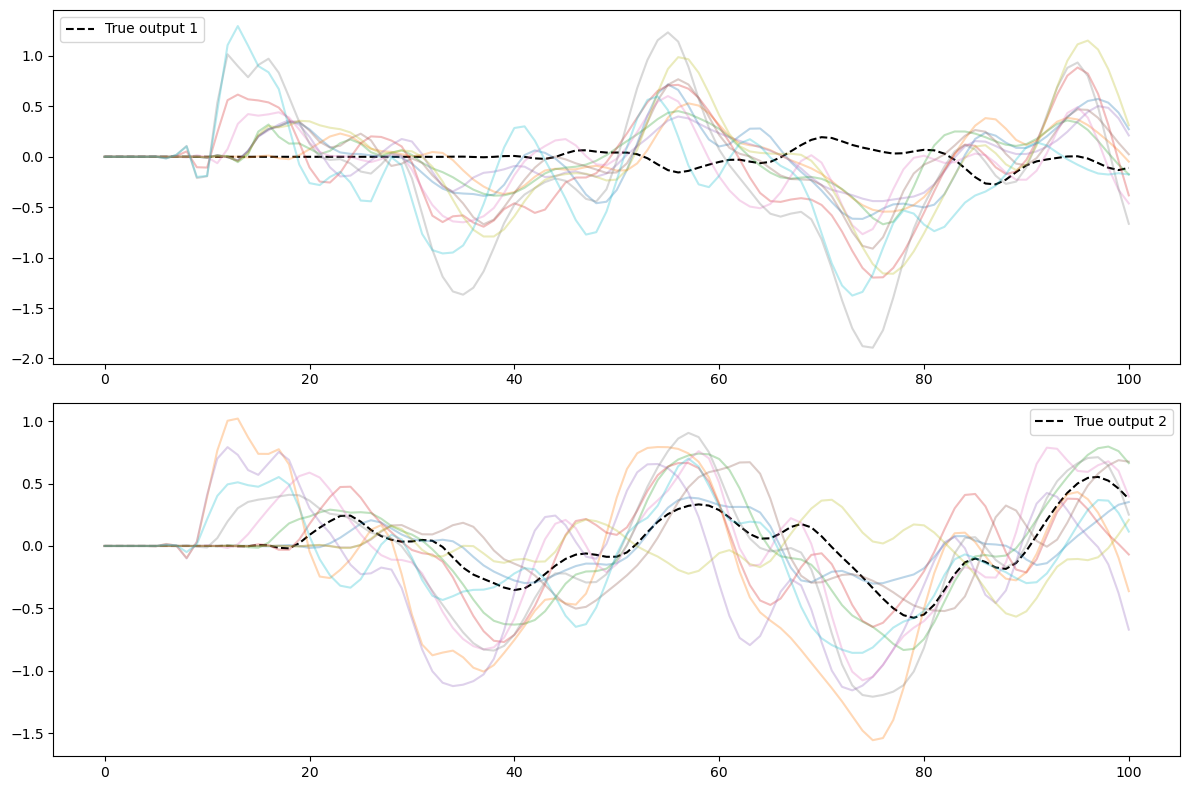

In [ ]:
# Plot outputs with likelihoods
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs_post:
    ax[0].plot(output[::2], alpha=0.3)
    ax[1].plot(output[1::2], alpha=0.3)
   
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Extract largest likelihoods for posterior
likelihoods = idata_sub.sample_stats["likelihood"].values[0, :]

# Sort parameter sets by decreasing likelihood
sorted_indices = np.argsort(-likelihoods)  # Negative for descending order
top_indices = sorted_indices[:5]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")

for i in top_indices:
    param = parameters[i]
    output = np.array(levelset_model(param))
    loglike = likelihoods[i]
    ax[0].plot(output[::2], alpha=0.3, label=f"loglike: {loglike:.2f}")
    ax[1].plot(output[1::2], alpha=0.3, label=f"loglike: {loglike:.2f}")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

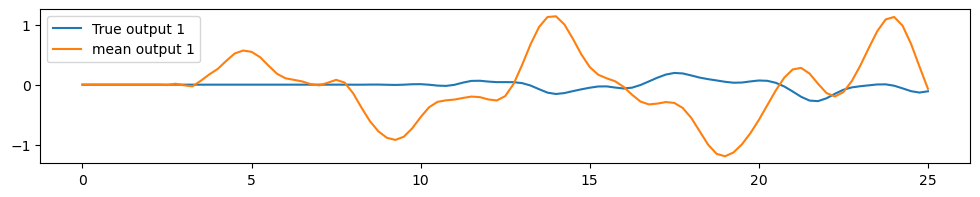

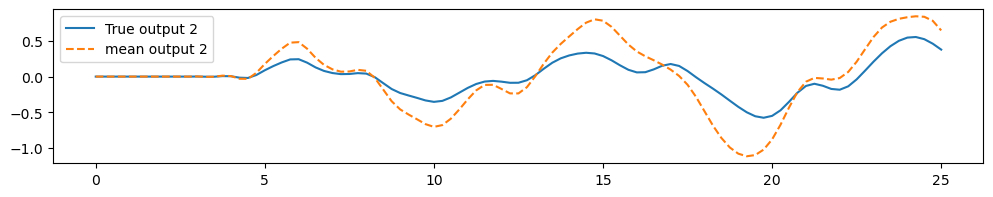

In [22]:
# Plot ouput from mean posterior
x=np.linspace(0,nx, nx)
t=np.linspace(0,25, int(ny/2))
d1 = np.array(d_true)[0:ny:2]
d2 = np.array(d_true)[1:ny:2]

output = levelset_model(info['mean'])
o1 = np.array(output)[0:ny:2]
o2 = np.array(output)[1:ny:2]

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d1, label='True output 1')
ax.plot(t,o1, label='mean output 1')
ax.legend()

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d2, label='True output 2')
ax.plot(t,o2, '--' ,label='mean output 2')
ax.legend()

### Compare draws from the prior to the true data

In [ ]:
# Evaluate model outputs and likelihoods
n_samples = 10

likelihoods_prior = []
outputs_prior = []

for ids in range(n_samples):
    log = my_prior.rvs()
    log = restriction(log)
    output = levelset_model(log)
    outputs_prior.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    likelihoods_prior.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods_prior = np.array(likelihoods_prior)
norm = colors.Normalize(vmin=np.min(likelihoods_prior), vmax=np.max(likelihoods_prior))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods_prior]


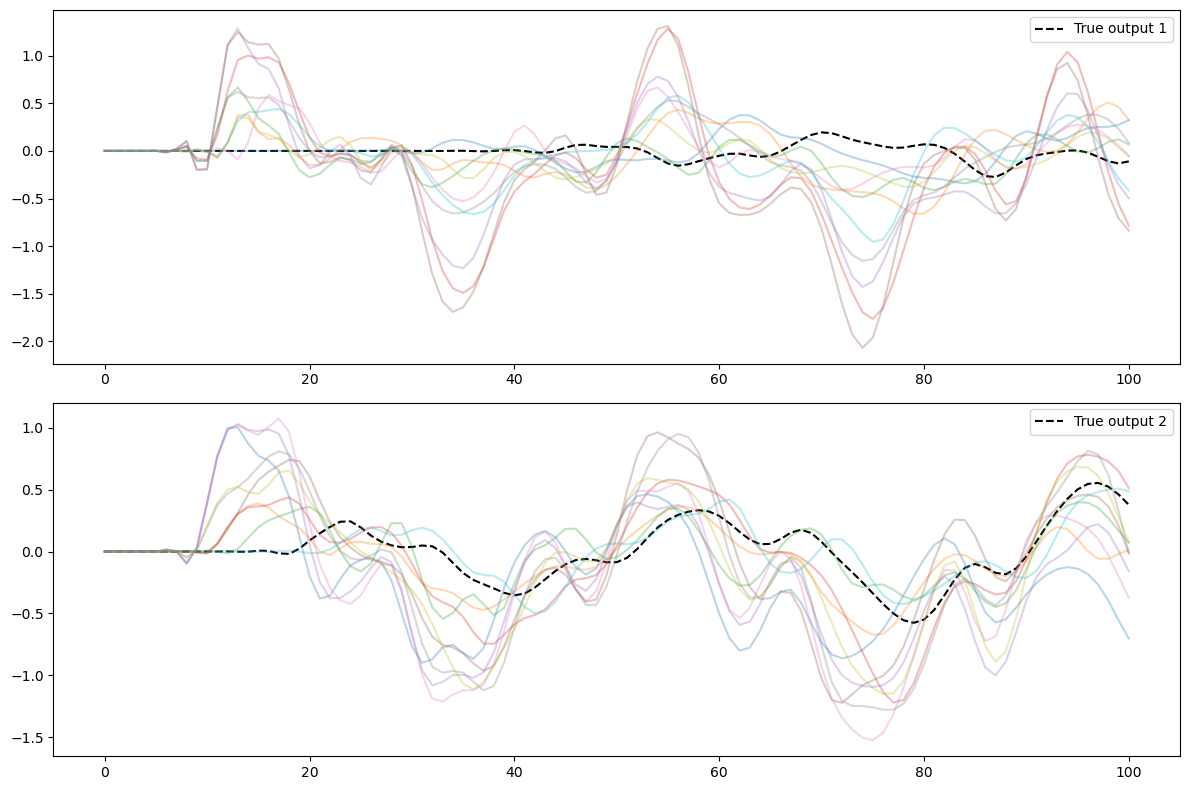

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs_prior:
    ax[0].plot(output[::2], alpha=0.3)
    ax[1].plot(output[1::2], alpha=0.3)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()